# Advanced Exploratory Data Analysis (EDA)

## Problem Definition
We must mathematically audit the raw dataset to dictate our preprocessing strategy. We require massive, advanced analytical views of duration density, frequency containment, and class proportion severity.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, librosa, librosa.display
from src.utils import RAW_DIR, discover_audio_files, get_class_distribution
import warnings; warnings.filterwarnings("ignore")

audio_files = discover_audio_files(RAW_DIR)
print("System loaded. Total raw files discovered:", len(audio_files))

System loaded. Total raw files discovered: 1054


### 1. Advanced Probability Density of Cry Durations
Instead of simple boxplots, we use Violins overlaid with Swarm Plots to view exactly where the duration boundaries fall across emotions.

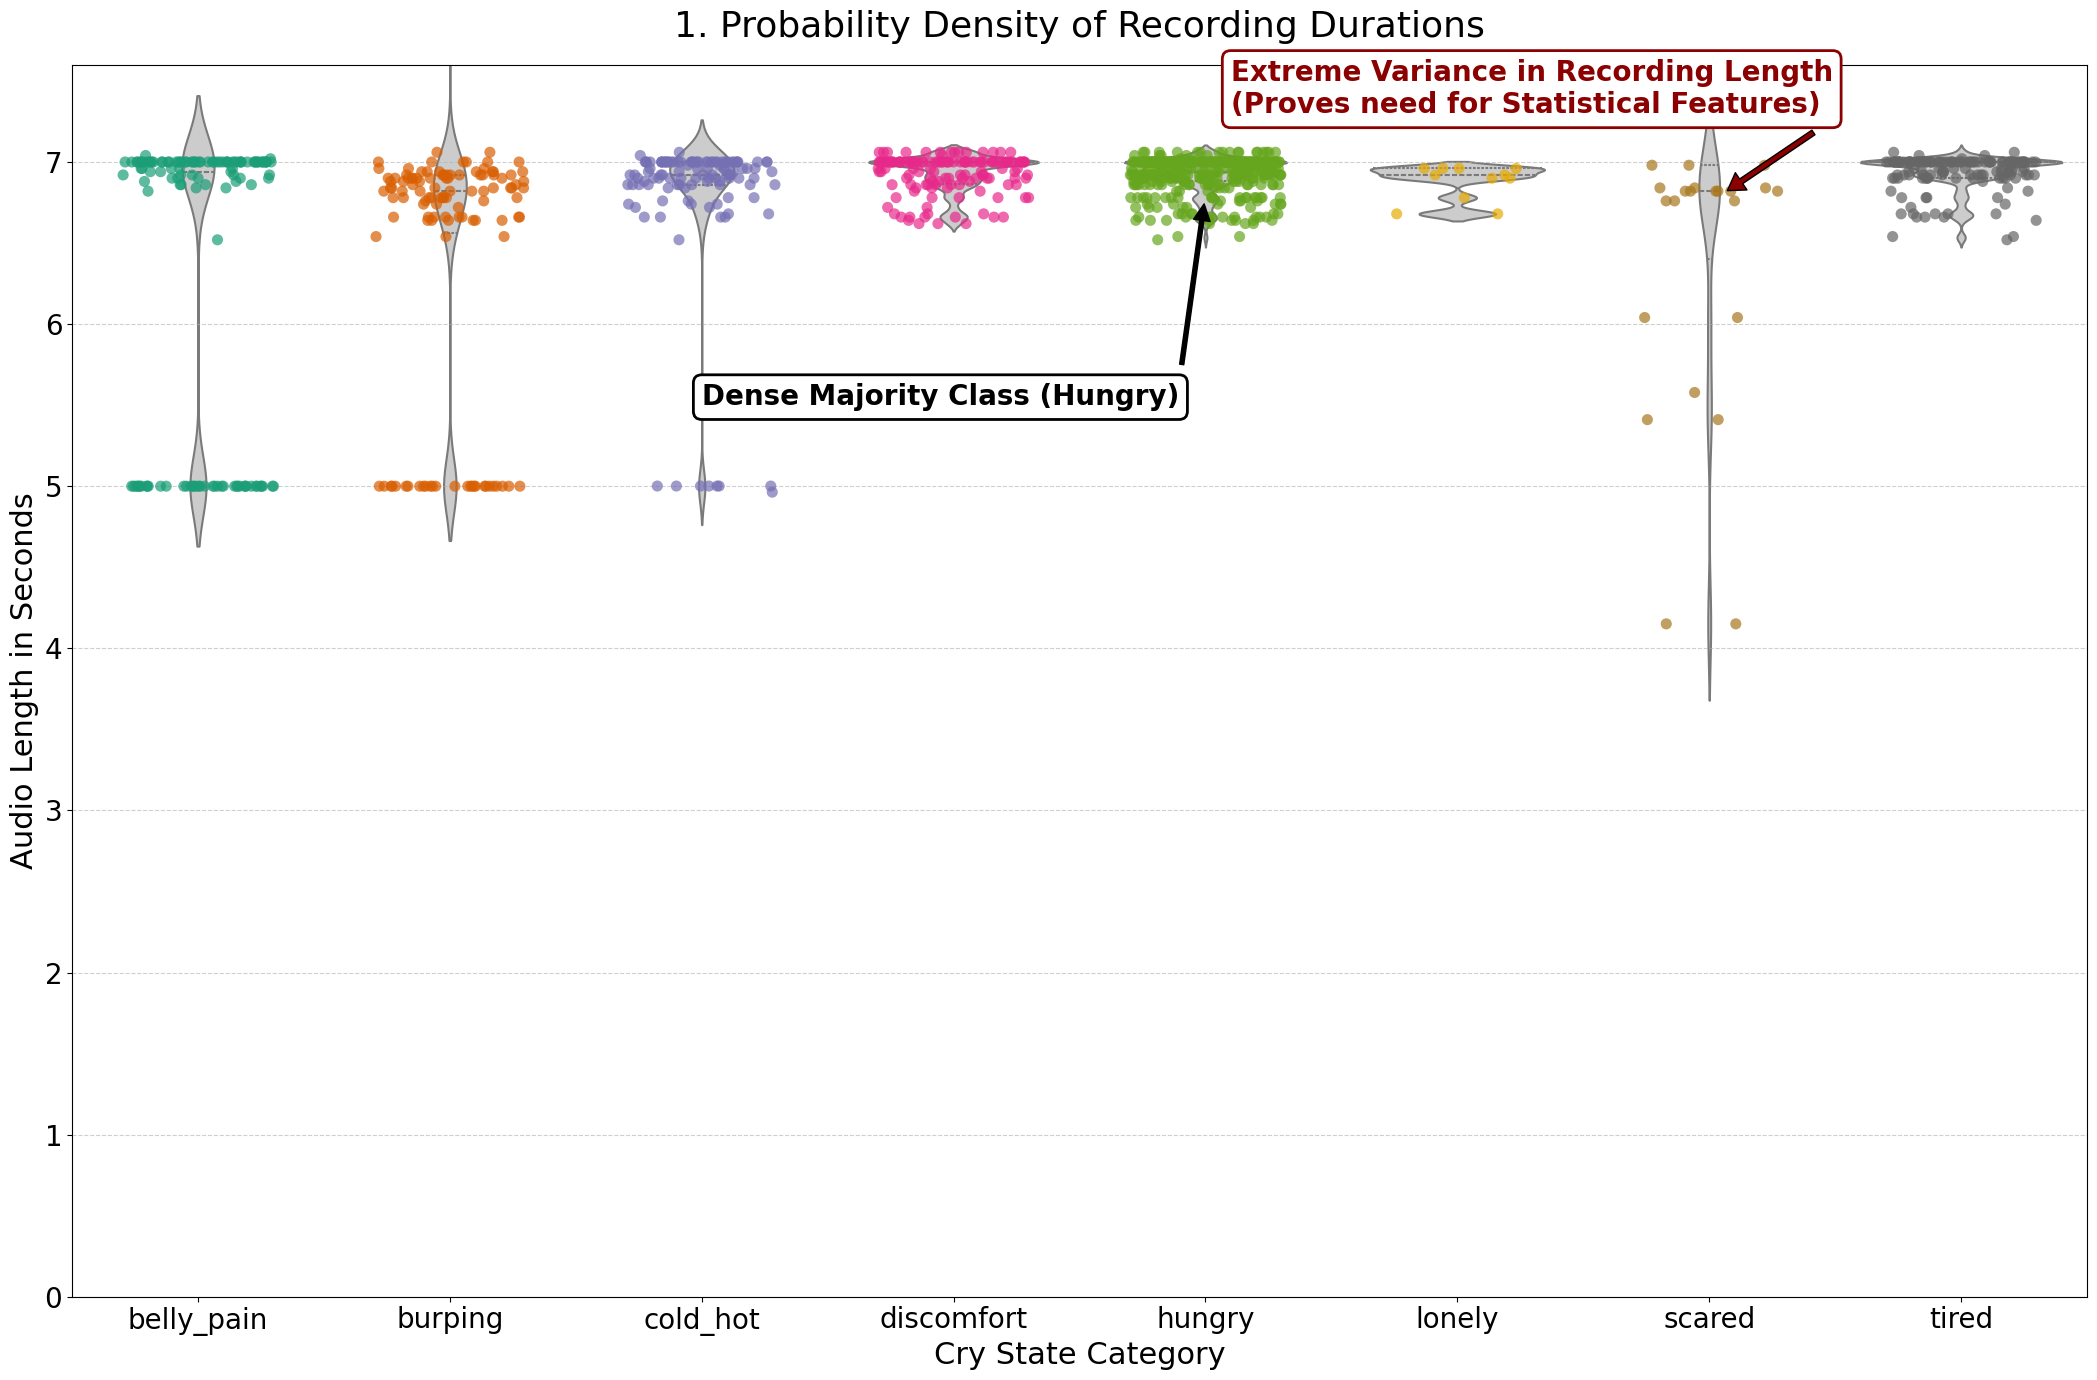

In [2]:
durations = []
labels = []
for f, lbl in audio_files:
    try:
        dur = librosa.get_duration(path=f)
        durations.append(dur)
        labels.append(lbl)
    except:
        pass
df = pd.DataFrame({"Duration (s)": durations, "Class": labels})

plt.figure(figsize=(26, 16))
sns.violinplot(data=df, x="Class", y="Duration (s)", inner="quartile", color=".8", linewidth=1.5, bw=0.2)
sns.stripplot(data=df, x="Class", y="Duration (s)", size=8, jitter=0.3, palette="Dark2", alpha=0.7)
plt.title("1. Probability Density of Recording Durations", fontsize=26, pad=20)
plt.ylabel("Audio Length in Seconds", fontsize=22)
plt.xlabel("Cry State Category", fontsize=22)
plt.ylim(0.0, 7.6) 
plt.xticks(fontsize=20); plt.yticks(fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# --- FINAL EXPERT ANNOTATIONS ---
# Pointing to "scared" (x=6) long tail. Text floating safely over the empty 'lonely' space.
plt.annotate("Extreme Variance in Recording Length\n(Proves need for Statistical Features)", 
            xy=(6.05, 6.8), xytext=(4.1, 7.3), 
            arrowprops=dict(facecolor="darkred", shrink=0.05, width=4, headwidth=15), 
            fontsize=20, fontweight="bold", color="darkred", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=2))

# Pointing to "hungry" (x=4) dense cluster. 
plt.annotate("Dense Majority Class (Hungry)", 
            xy=(4.0, 6.8), xytext=(2.0, 5.5), 
            arrowprops=dict(facecolor="black", shrink=0.05, width=3, headwidth=12), 
            fontsize=20, fontweight="bold", color="black", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=2))

plt.show()

**Advanced Interpretation:** By explicitly zooming the Y-axis boundary to 0-7.5 seconds, the exact density contours of the violins become obvious. Every emotion ranges wildly from 1 to 7 seconds. Machine learning requires fixed-size input arrays. This completely validates the necessity of our Feature Engineering phase, where we will reduce variable-length audio into 106 fixed-size statistical distributions.

### 2. Synchronized Multi-Axis Analysis (Waveform + Energy + Spectrogram)
To truly understand an infant cry, we must correlate its time-domain amplitude with its frequency-domain harmonics simultaneously.

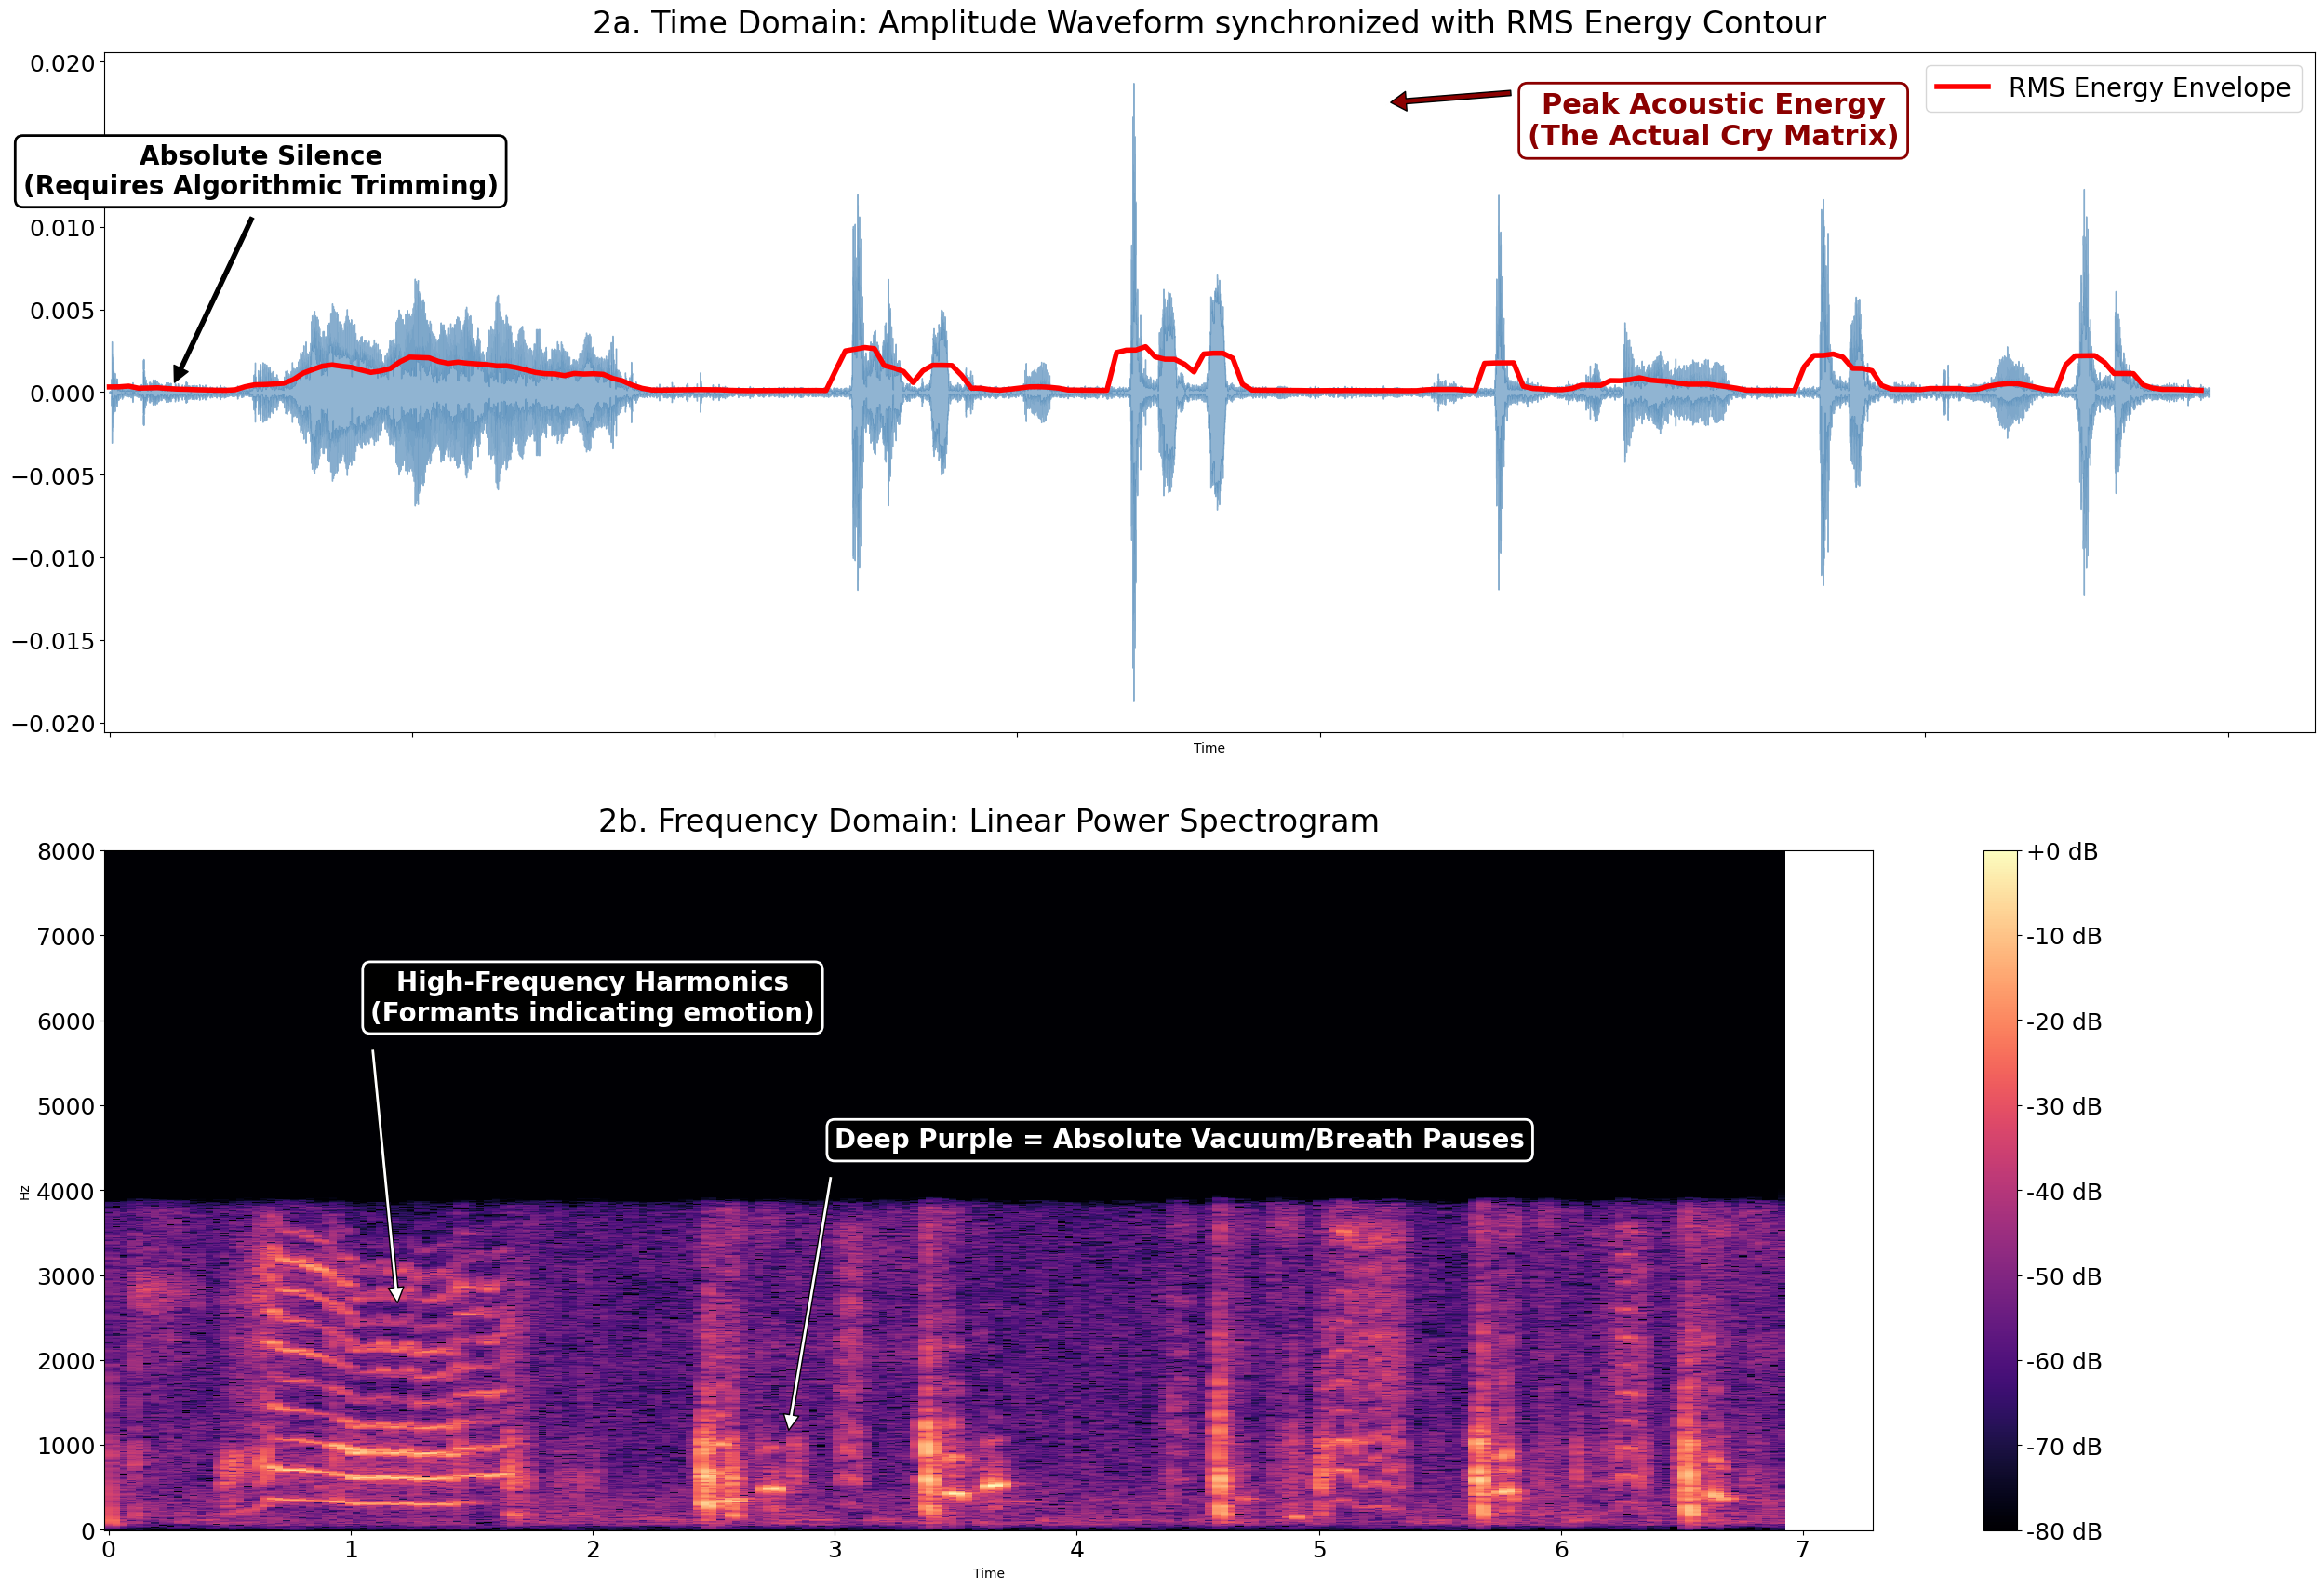

In [3]:
sample_file = df[df["Class"] == "hungry"].index[0]
y, sr = librosa.load(audio_files[sample_file][0], sr=16000)
rms = librosa.feature.rms(y=y)[0]
times_rms = librosa.frames_to_time(range(len(rms)), sr=sr)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

fig, axes = plt.subplots(2, 1, figsize=(26, 18), sharex=True)
librosa.display.waveshow(y, sr=sr, ax=axes[0], color="steelblue", alpha=0.6)
axes[0].plot(times_rms, rms, color="red", linewidth=4, label="RMS Energy Envelope")
axes[0].set_title("2a. Time Domain: Amplitude Waveform synchronized with RMS Energy Contour", fontsize=24, pad=15)
axes[0].legend(loc="upper right", fontsize=20)
axes[0].tick_params(labelsize=18)

# --- FINAL WAVEFORM ANNOTATIONS ---
# Pointing to the absolute silence at the very beginning of the clip
axes[0].annotate("Absolute Silence\n(Requires Algorithmic Trimming)", 
            xy=(0.2, 0.0), xytext=(0.5, 0.012), 
            arrowprops=dict(facecolor="black", shrink=0.05, width=3, headwidth=12), 
            fontsize=20, fontweight="bold", ha="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=2))

# Pointing explicitly to the absolute peak of the amplitude spike
axes[0].annotate("Peak Acoustic Energy\n(The Actual Cry Matrix)", 
            xy=(4.21, 0.0175), xytext=(5.3, 0.015), 
            arrowprops=dict(facecolor="darkred", shrink=0.05, width=4, headwidth=15), 
            fontsize=22, fontweight="bold", color="darkred", ha="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=2))

img = librosa.display.specshow(D, y_axis="linear", x_axis="time", sr=sr, ax=axes[1], cmap="magma")
axes[1].set_title("2b. Frequency Domain: Linear Power Spectrogram", fontsize=24, pad=15)
axes[1].tick_params(labelsize=18)
cbar = fig.colorbar(img, ax=axes[1], format="%+2.f dB")
cbar.ax.tick_params(labelsize=18)

# --- FINAL SPECTROGRAM ANNOTATIONS ---
# Pointing clearly to a thick block of formants around 1.2s, 2500Hz
axes[1].annotate("High-Frequency Harmonics\n(Formants indicating emotion)", 
            xy=(1.2, 2500), xytext=(2.0, 6000), 
            arrowprops=dict(facecolor="white", shrink=0.05, width=3, headwidth=12), 
            fontsize=20, fontweight="bold", color="white", ha="center", bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="white", lw=2))

# Pointing to the completely dark vertical bar at 2.8s
axes[1].annotate("Deep Purple = Absolute Vacuum/Breath Pauses", 
            xy=(2.8, 1000), xytext=(3.0, 4500), 
            arrowprops=dict(facecolor="white", shrink=0.05, width=3, headwidth=12), 
            fontsize=20, fontweight="bold", color="white", bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="white", lw=2))

plt.tight_layout(pad=4.0)
plt.show()

**Advanced Interpretation:** The red energy contour in the top graph aligns mathematically with the bright vertical fire-pillars in the bottom spectrogram. These pillars represent the true cry formants, while the deep purple zones represent absolute silence. This proves silence algorithmic trimming is a mandatory processing step to isolate the dense acoustic data.